It's surprisingly fast to obtain conformal [jackknife+](https://projecteuclid.org/journalArticle/Download?urlId=10.1214%2F20-AOS1965) prediction intervals for Machine Learning models of the form $$\hat{y} = Sy$$ (including Ordinary
Least Squares, Ridge Regression, Random Vector Functional Link Networks,
Kernel Ridge Regression, smoothing splines, and local polynomial regression). **No refitting involved, just Linear Algebra**. Read [https://www.researchgate.net/publication/408161842_Fast_Conformal_Prediction_for_Some_Machine_Learning_Models_via_Closed-Form_Jackknife](https://www.researchgate.net/publication/408161842_Fast_Conformal_Prediction_for_Some_Machine_Learning_Models_via_Closed-Form_Jackknife).  


Here are Python and R examples:

# 1 - R version

In [10]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython



Lambda = 1 
  Asymmetric: coverage=0.914 (target 0.90), width=14.89
  Symmetric:   coverage=0.928 (target 0.90), width=14.78

Lambda = 10 
  Asymmetric: coverage=0.914 (target 0.90), width=14.99
  Symmetric:   coverage=0.934 (target 0.90), width=14.93

Lambda = 50 
  Asymmetric: coverage=0.947 (target 0.90), width=16.07
  Symmetric:   coverage=0.914 (target 0.90), width=14.89


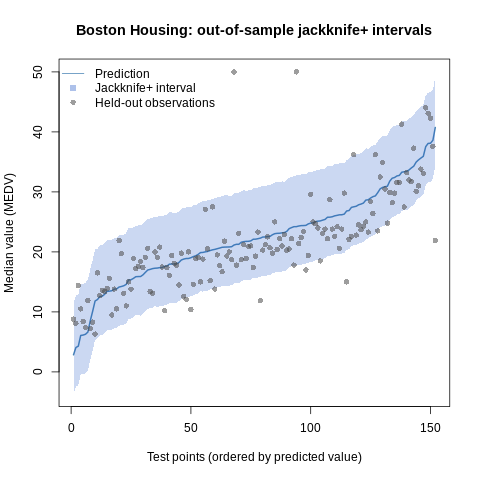

In [11]:
%%R

library(MASS)

jackknife_plus <- function(X_train, y_train, X_test, lambda = 1,
                           alpha = 0.1, symmetric = FALSE) {
  # Center response (intercept not penalized)
  ybar <- mean(y_train)
  yc <- y_train - ybar

  # Ridge solution
  A <- t(X_train) %*% X_train + lambda * diag(ncol(X_train))
  A_inv <- solve(A)
  beta <- A_inv %*% t(X_train) %*% yc

  # Closed-form LOO residuals (memory efficient)
  h <- rowSums((X_train %*% A_inv) * X_train)  # diag(X_train %*% A_inv %*% t(X_train))
  e <- as.numeric(yc - X_train %*% beta)       # in-sample residuals
  r <- e / pmax(1 - h, 1e-10)                  # LOO residuals

  # Full-data predictions on test set
  yhat_test <- as.numeric(X_test %*% beta) + ybar

  # Cross-term: n_test x n_train
  G <- X_test %*% A_inv %*% t(X_train)

  # f^{-i}(x_j) = f(x_j) - G[j,i] * r_i (Sherman-Morrison)
  loo_pred <- yhat_test - sweep(G, 2, r, `*`)

  if (symmetric) {
    # Symmetric version: use absolute residuals
    scores <- abs(loo_pred - yhat_test) + abs(rep(r, each = nrow(X_test)))
    q <- apply(scores, 1, quantile, probs = 1 - alpha)
    lo <- yhat_test - q
    hi <- yhat_test + q
  } else {
    # Asymmetric version: use signed residuals
    scores <- loo_pred + rep(r, each = nrow(X_test))
    lo <- apply(scores, 1, quantile, probs = alpha / 2)
    hi <- apply(scores, 1, quantile, probs = 1 - alpha / 2)
  }

  list(pred = yhat_test, lo = lo, hi = hi)
}

# Boston Housing example
set.seed(1)
data(Boston)
X <- scale(as.matrix(Boston[, -14]))
y <- Boston$medv
n <- nrow(X)

idx <- sample(seq_len(n))
n_train <- floor(0.7 * n)
train_i <- idx[1:n_train]
test_i <- idx[(n_train + 1):n]

for (lambda in c(1, 10, 50)) {
  cat("\nLambda =", lambda, "\n")

  # Asymmetric version
  res <- jackknife_plus(X[train_i, ], y[train_i], X[test_i, ],
                        lambda = lambda, alpha = 0.1, symmetric = FALSE)
  cov <- mean(y[test_i] >= res$lo & y[test_i] <= res$hi)
  width <- mean(res$hi - res$lo)
  cat(sprintf("  Asymmetric: coverage=%.3f (target 0.90), width=%.2f\n", cov, width))

  # Symmetric version
  res_sym <- jackknife_plus(X[train_i, ], y[train_i], X[test_i, ],
                            lambda = lambda, alpha = 0.1, symmetric = TRUE)
  cov_sym <- mean(y[test_i] >= res_sym$lo & y[test_i] <= res_sym$hi)
  width_sym <- mean(res_sym$hi - res_sym$lo)
  cat(sprintf("  Symmetric:   coverage=%.3f (target 0.90), width=%.2f\n", cov_sym, width_sym))
}

# Best performing model (lambda=10) for visualization
res_best <- jackknife_plus(X[train_i, ], y[train_i], X[test_i, ],
                           lambda = 10, alpha = 0.1, symmetric = FALSE)

ord <- order(res_best$pred)
y_test_ord <- y[test_i][ord]
x_axis <- seq_along(ord)

plot(x_axis, res_best$pred[ord],
     type = "l", col = "steelblue", lwd = 2,
     ylim = range(c(res_best$lo, res_best$hi, y_test_ord)),
     xlab = "Test points (ordered by predicted value)",
     ylab = "Median value (MEDV)",
     main = "Boston Housing: out-of-sample jackknife+ intervals")

polygon(c(x_axis, rev(x_axis)),
        c(res_best$hi[ord], rev(res_best$lo[ord])),
        col = rgb(0.2, 0.4, 0.8, 0.25), border = NA)

points(x_axis, y_test_ord, pch = 16, col = rgb(0.3, 0.3, 0.3, 0.55))

legend("topleft",
       legend = c("Prediction", "Jackknife+ interval", "Held-out observations"),
       col = c("steelblue", rgb(0.2, 0.4, 0.8, 0.4), rgb(0.3, 0.3, 0.3, 0.55)),
       lty = c(1, NA, NA), pch = c(NA, 15, 16), bty = "n")

# 2 - Python version

In [ ]:
!pip install mlsauce

Model                       Coverage      Width       RMSE
----------------------------------------------------------------------
Elapsed: 0.003574848175048828
Plain Ridge                   0.902     182.00      54.56
Elapsed: 0.01886749267578125
RVFL (asymmetric)             0.880     176.86      53.91
Elapsed: 0.01717209815979004
RVFL (symmetric)              0.895     182.16      53.91


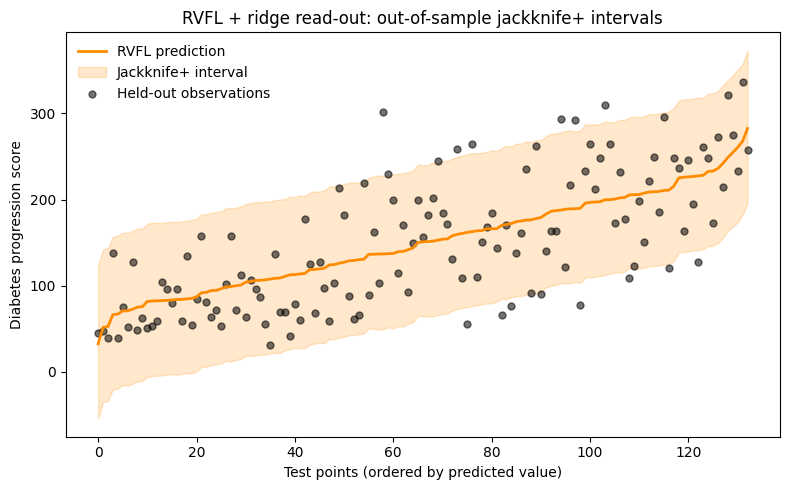


Saved plot to rvfl_jackknife_plus.png


In [13]:
import matplotlib.pyplot as plt
import mlsauce as ms
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from time import time

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

alpha = 0.10

print("=" * 70)
print(f"{'Model':25s} {'Coverage':>10s} {'Width':>10s} {'RMSE':>10s}")
print("-" * 70)

for name, model in [
    ("Plain Ridge", ms.RVFLJackknifePlus(n_hidden=0, lambda_=50.0)),
    ("RVFL (asymmetric)", ms.RVFLJackknifePlus(n_hidden=200, lambda_=50.0, symmetric=False)),
    ("RVFL (symmetric)", ms.RVFLJackknifePlus(n_hidden=200, lambda_=50.0, symmetric=True)),
]:
    start = time()
    model.fit(X_train, y_train)
    pred = model.predict(X_test, alpha=alpha, return_pi=True)
    print(f"Elapsed: {time() - start}")

    cov = np.mean((y_test >= pred.lower) & (y_test <= pred.upper))
    width = np.mean(pred.upper - pred.lower)
    rmse = np.sqrt(mean_squared_error(y_test, pred.mean))

    print(f"{name:25s} {cov:9.3f}  {width:9.2f}  {rmse:9.2f}")

# ---- Plot: RVFL out-of-sample jackknife+ band ----
# Use the asymmetric RVFL model for visualization
model_best = ms.RVFLJackknifePlus(n_hidden=200, lambda_=50.0, symmetric=False)
model_best.fit(X_train, y_train)
pred_rvfl = model_best.predict(X_test, alpha=alpha, return_pi=True)

order = np.argsort(pred_rvfl.mean)
x_axis = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_axis, pred_rvfl.mean[order], color="darkorange", lw=2, label="RVFL prediction")
ax.fill_between(
    x_axis, pred_rvfl.lower[order], pred_rvfl.upper[order],
    color="darkorange", alpha=0.20, label="Jackknife+ interval",
)
ax.scatter(
    x_axis, y_test[order], color="black", alpha=0.55, s=25,
    label="Held-out observations",
)
ax.set_xlabel("Test points (ordered by predicted value)")
ax.set_ylabel("Diabetes progression score")
ax.set_title("RVFL + ridge read-out: out-of-sample jackknife+ intervals")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
plt.savefig("rvfl_jackknife_plus.png", dpi=150)
plt.show()
print("\nSaved plot to rvfl_jackknife_plus.png")